**Завдання звучить так:**

Розрахуй фактичний LTV за заданий період та предикт для кожної тижневої або
місячної когорти на пів року з використанням Python.


Опиши обраний підхід та оціни якість розрахунку, запропонуй варіанти, як можна
покращити точність предикту.


*В якості когортного івента використовуй перший платіжний івент



## Розрахуємо спершу фактичний LTV

In [1]:
import pandas as pd

df = pd.read_csv('/content/drive/MyDrive/Курс Дата аналітик /Data/ТЗ /KissMyApps/Data Analyst Test Task Data new Yana - Tasks 1-2.csv', parse_dates=['event_timestamp'],decimal=',' )

In [2]:
#Обираю тільки покупки
df = df[df['event_name'] == 'purchase']
df.head(5)

,uuid,event_timestamp,event_name,product_id,is_trial,period,trial_period,revenue_usd,transaction_id,refunded_transaction_id
3,00026e14-e302-4772-b691-8b0e67ab0c32,2023-06-05 23:10:44,purchase,weekly.2.49,False,7,0,2.49,b672df8a-fcb2-4737-8a5f-98a85b183609,NaN
4,00026e14-e302-4772-b691-8b0e67ab0c32,2023-06-12 23:10:57,purchase,weekly.2.49,False,7,0,2.49,33254b74-1437-4eb1-a71d-be3c0958bdf8,NaN
5,00026e14-e302-4772-b691-8b0e67ab0c32,2023-06-20 23:10:53,purchase,weekly.2.49,False,7,0,2.49,b0e50445-f8bb-4677-86c9-e34f49a274ab,NaN
6,00026e14-e302-4772-b691-8b0e67ab0c32,2023-06-27 23:10:46,purchase,weekly.2.49,False,7,0,2.49,4e9a3204-f64c-4e7f-b2ec-ebbbb813b142,NaN
7,00026e14-e302-4772-b691-8b0e67ab0c32,2023-07-04 23:10:37,purchase,weekly.2.49,False,7,0,2.49,be75126f-e581-49fc-a84c-8ed682c8d4ca,NaN


In [3]:
# Визначаю дату першої покупки
df['first_purchase_date'] = df.groupby('uuid')['event_timestamp'].transform('min')

Буду робити аналіз тижневої кагорти, бо продукт має місячну підписку, це буде доречніше.

In [4]:
# Переводжу дату першої покупки у початок тижня
df['cohort_week'] = df['first_purchase_date'].dt.to_period('W').apply(lambda r: r.start_time)

# Повторюю з тижднем транзакції (щоб відстежити зсув)
df['transaction_week'] = df['event_timestamp'].dt.to_period('W').apply(lambda r: r.start_time)

In [5]:
# Рахую зсув (в тижнях)
df['cohort_week_index'] = ((df['transaction_week'] - df['cohort_week']).dt.days // 7)

In [6]:
# Рахую дохід по когорті та номеру тижня з моменту першої покупки
cohort_data = df.groupby(['cohort_week', 'cohort_week_index'])['revenue_usd'].sum().reset_index()

In [7]:
# LTV - накопичений дохід
cohort_data['ltv'] = cohort_data.groupby('cohort_week')['revenue_usd'].cumsum()

In [8]:
# Побудую таблицю
ltv_matrix = cohort_data.pivot(
    index='cohort_week',
    columns='cohort_week_index',
    values='ltv'
)
ltv_matrix.head(10)

cohort_week_index,0,1,2,3,4,5,6,7,8,9,...,27,28,29,30,31,32,33,34,35,36
cohort_week,,,,,,,,,,,,,,,,,,,,,
2023-02-27,206.61111,261.47111,331.26111,386.10111,442.61985,527.26525,601.95424,674.31424,756.64424,830.97868,...,1756.11380,1798.55380,1826.01380,1860.95380,1895.89380,1935.83380,1968.29380,1988.27380,2008.25380,2018.2438
2023-03-06,1190.92880,1623.47792,1992.26248,2305.54096,2846.42956,3449.12957,3916.86327,4377.69369,4764.15425,5149.48215,...,9424.62136,9534.39136,9658.86386,9782.47539,9882.28539,9962.52815,10005.30938,10052.74938,10092.69938,NaN
2023-03-13,893.56024,1117.00362,1333.82905,1503.67212,1889.08343,2261.04572,2597.67100,2894.03044,3245.93044,3447.44935,...,6042.73379,6107.59379,6191.78327,6255.72522,6298.15522,6318.13522,6338.11522,6362.63271,NaN,NaN
2023-03-20,873.24300,1160.74050,1395.28121,1580.58395,1956.98671,2293.99914,2546.35483,2818.62645,3043.30438,3275.27169,...,5560.15723,5628.57314,5675.20662,5722.64662,5750.11662,5792.42133,5802.41133,NaN,NaN,NaN
2023-03-27,711.41701,910.86701,1062.93701,1175.11701,1564.39586,1868.85586,2132.55994,2340.84187,2545.49187,2753.45568,...,4675.01998,4732.41998,4753.60675,4801.05675,4828.52675,4858.49675,NaN,NaN,NaN,NaN
2023-04-03,583.30362,773.75571,898.51281,1018.48290,1246.89412,1550.20865,1724.86865,1978.03079,2179.66470,2347.06053,...,4220.99489,4254.40775,4311.84775,4366.78775,4376.77775,NaN,NaN,NaN,NaN,NaN
2023-04-10,457.86641,638.59333,797.37019,925.84673,1115.40192,1338.91640,1526.04640,1642.69681,1754.92058,1872.72484,...,2960.60205,2985.57205,2995.56205,3003.05205,NaN,NaN,NaN,NaN,NaN,NaN
2023-04-17,671.94541,940.39914,1154.28429,1342.65932,1721.39098,2099.60961,2415.51692,2702.01056,2936.80158,3168.90159,...,5295.87166,5310.85166,5318.34166,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2023-04-24,788.10193,1011.92359,1206.40359,1372.76884,1685.83172,2131.28057,2450.02483,2703.50470,2980.54696,3214.88051,...,6019.10866,6086.53866,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Всі кагорти не вийде зобразити, тому я хочу обрати три ключові когорти за фінальним LTV:


* Найвищий — топова когорта

* Середній — когорта ближча до медіанного LTV

* Найнижчий — когорта з найменшим фінальним результатом

In [9]:
# Фінальний (максимальний) LTV для кожної когорти
final_ltv = cohort_data.groupby('cohort_week')['ltv'].max().sort_values()

# Найнижчий
lowest = final_ltv.idxmin()

# Найвищий
highest = final_ltv.idxmax()

# Середній (медіана)
median_val = final_ltv.median()
middle = (final_ltv - median_val).abs().idxmin()

# Формую список обраних когорт
selected_cohorts = [lowest, middle, highest]

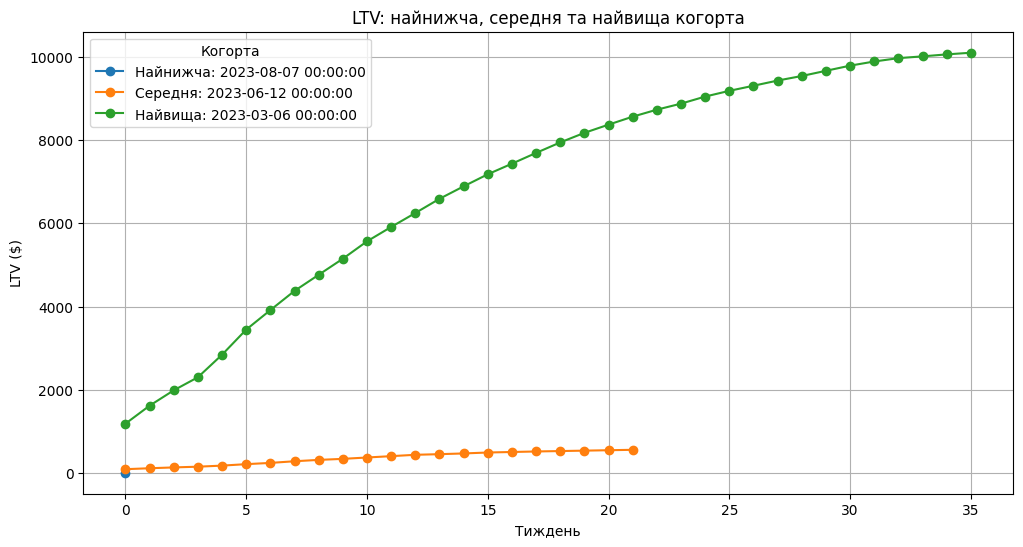

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

subset1 = cohort_data[cohort_data['cohort_week'] == selected_cohorts[0]]
subset2 = cohort_data[cohort_data['cohort_week'] == selected_cohorts[1]]
subset3 = cohort_data[cohort_data['cohort_week'] == selected_cohorts[2]]

plt.figure(figsize=(12, 6))

plt.plot(subset1['cohort_week_index'], subset1['ltv'], marker='o', label=f'Найнижча: {selected_cohorts[0]}')
plt.plot(subset2['cohort_week_index'], subset2['ltv'], marker='o', label=f'Середня: {selected_cohorts[1]}')
plt.plot(subset3['cohort_week_index'], subset3['ltv'], marker='o', label=f'Найвища: {selected_cohorts[2]}')

plt.title("LTV: найнижча, середня та найвища когорта")
plt.xlabel("Тиждень")
plt.ylabel("LTV ($)")
plt.legend(title="Когорта")
plt.grid(True)
plt.show();

In [11]:
# Хочу перевірити інформацію про Найнижчу когорту
cohort_data[cohort_data['cohort_week'] == selected_cohorts[0]]

,cohort_week,cohort_week_index,revenue_usd,ltv
573,2023-08-07,0,14.97,14.97


Це нова кагорта, тому на графіку у нас одна точка

**Висновок:**

* **Найвища когорта** — 2023-03-06 з фінальним LTV ≈ $10.200.

Ця когорта має стабільне зростання протягом понад 30 тижнів.

* **Середня когорта** — 2023-06-12 з LTV ≈ $650.

Має хорошу динаміку, але значно нижчу за лідера.

* **Найнижча когорта** — 2023-08-07 з лише $15 і одним тижнем активності.



**Різниця між кращою та гіршою когортами — $10.000, що вказує на різке коливання ефективності між періодами.**

## Перейдемо до прогнозування

Не володію інформацією поки про моделі, якими можна визначати прогноз, тому буду будувати його простішим способом.

А саме, можна подивитись як зростає LTV по тижнях, і просто продовжити таку саму динаміку ще на тижні вперед. В завданні вказано про пів року, а це приблизно 26 тижнів.

In [13]:
import numpy as np

ltv_forecast_rows = []

for cohort in cohort_data['cohort_week'].unique():
    subset = cohort_data[cohort_data['cohort_week'] == cohort].copy() #створюємо окрему таблицю для когорти окремим обʼєктом
    weeks = subset['cohort_week_index'].values
    ltv = subset['ltv'].values

    for w, l in zip(weeks, ltv):
        ltv_forecast_rows.append({
            'cohort_week': cohort,
            'cohort_week_index': w,
            'ltv': l,
            'source': 'fact'
        })

    if len(ltv) >= 3:
        growth = np.mean(np.diff(ltv[-3:]))  # останні 3 тижні
        last_week = weeks[-1]
        last_ltv = ltv[-1]

        # прогноз на 4 тижні вперед
        future_weeks = np.arange(last_week + 1, last_week + 27) # прогноз на 27 тижнів
        future_ltv = [last_ltv + growth * (i - last_week) for i in future_weeks]

        for fw, fl in zip(future_weeks, future_ltv):
            ltv_forecast_rows.append({
                'cohort_week': cohort,
                'cohort_week_index': fw,
                'ltv': fl,
                'source': 'forecast'
            })

ltv_full = pd.DataFrame(ltv_forecast_rows)

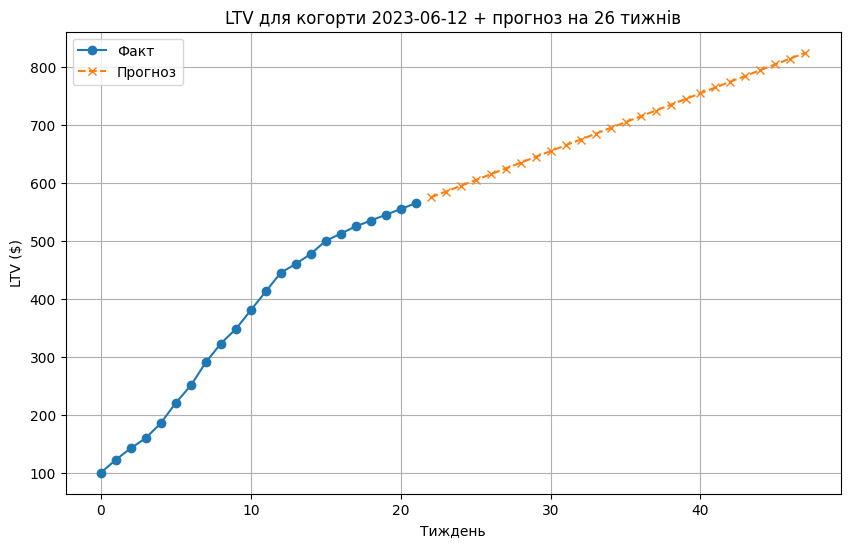

In [14]:
# Виберемо одну кагорту для прикладу (середню)
cohort_to_plot = '2023-06-12'
subset = ltv_full[ltv_full['cohort_week'] == cohort_to_plot]

plt.figure(figsize=(10, 6))

# Факт
fact = subset[subset['source'] == 'fact']
plt.plot(fact['cohort_week_index'], fact['ltv'], marker='o', label='Факт')

# Прогноз
forecast = subset[subset['source'] == 'forecast']
plt.plot(forecast['cohort_week_index'], forecast['ltv'], marker='x', linestyle='--', label='Прогноз')

plt.title(f"LTV для когорти {cohort_to_plot} + прогноз на 26 тижнів")
plt.xlabel("Тиждень")
plt.ylabel("LTV ($)")
plt.legend()
plt.grid(True)
plt.show();

### Що зробила


Припустила, що якщо когорта має щонайменше 3 тижні даних, ми обчислюємо середній приріст LTV за останні 3 тижні.

Цей приріст використовується для екстраполяції майбутнього LTV на 26 тижнів вперед (≈ пів року).

**Переваги способу:**

* Простий у реалізації та поясненні (підходить для бізнес-команд)

* Не вимагає складного моделювання чи обчислювальних ресурсів

* Легко масштабується на всі когорти

* Можна регулярно оновлювати без зміни логіки


**Обмеження прогнозу:**
* Не враховує сезонність (наприклад, свята, рекламні кампанії)

* Прогноз базується лише на останніх тижнях — чутливий до шуму або випадкових стрибків

* Якби була падаюча когорта з негативним приростом то міг би вийти нереалістичний спад прогнозу

### Як покращити точність прогнозу LTV

**Можна було б:**
- *сегментувати користувачів*

Наприклад, за частотою покупок, типом підписки. Можна будувати окремі прогнози для кожного сегмента — це підвищує точність і адаптивність.

- *виключити нові когорти*

Якщо когорти мають тільки 1–2 тижні даних, їх прогноз має низьку якість.

- *перевірити підозрілі стрибки*

Якщо за останній тиждень LTV сильно виріс - то потрібно подумати чи можемо там використати середнє значення за останній час.

